# 02 – Spectrum preprocessing and dataset (Version 0.2)

Inspects the processed *E. coli* + ciprofloxacin dataset built by `scripts/build_dataset.py`. **No model is trained here.**

Build it first (from the project root):
```
python scripts/build_dataset.py
```

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import exploration as ex
from src.data_loader import read_raw_spectrum
from src.dataset import load_dataset, resolve_relpath
from src.preprocessing import PreprocessingConfig
from src.splits import load_splits
from src.utils import driams_root, load_config, project_path

config = load_config(PROJECT_ROOT / "config.yaml")
pcfg = PreprocessingConfig.from_config(config)
data_dir = project_path(config["dataset"]["output_dir"]) / config["dataset"]["name"]
X, meta, summary = load_dataset(data_dir)   # X is memory-mapped, not copied into RAM
print(X.shape, X.dtype, summary['x_megabytes'], 'MB; rows fingerprint', summary['row_fingerprint'])

(4472, 6000) float32 107.33 MB; rows fingerprint b4c1a749b8bab87a


## 1. Preprocessing definition

In [2]:
pd.Series(pcfg.to_dict())

intensity_transform              sqrt
smoothing_method       savitzky_golay
half_window_size                   10
polynomial_order                    3
baseline_method                  snip
baseline_iterations         [20, 100]
normalization                     tic
mz_min                         2000.0
mz_max                        20000.0
bin_width                         3.0
dtype                         float32
min_raw_points                    100
spectrum_folder                   raw
n_bins                           6000
dtype: object

## 2. Samples per site and exclusions

In [3]:
display(pd.DataFrame(summary['per_site']).T[['target_species_rows', 'samples', 'resistant', 'susceptible', 'excluded']])
pd.DataFrame([{'reason': r, **c} for r, c in summary['exclusions_by_reason'].items()]).fillna(0)

,target_species_rows,samples,resistant,susceptible,excluded
DRIAMS-A,7320,4259,971,3288,3061
DRIAMS-B,838,213,59,154,625


,reason,DRIAMS-A,DRIAMS-B
0,no_ast_result,2334,625.0
1,ambiguous_ast_result,75,0.0
2,excluded_workstation,633,0.0
3,malformed_spectrum,8,0.0
4,differs_from_driams_binned,11,0.0


## 3. One spectrum before and after preprocessing (no identifiers shown)

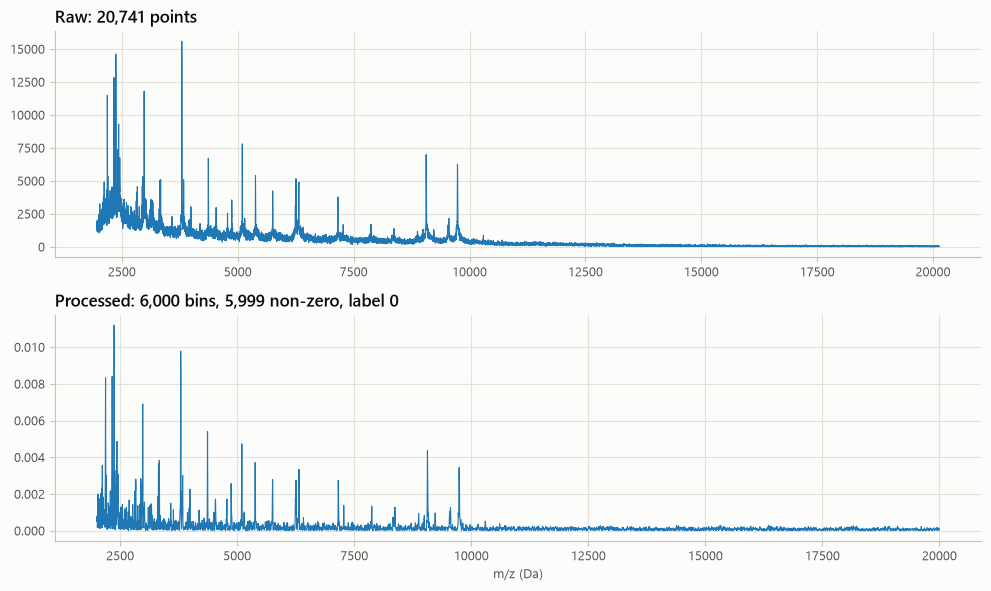

In [4]:
ex.apply_style()
row = 0
r = meta.iloc[row]
raw = read_raw_spectrum(resolve_relpath(driams_root(config), r['spectrum_relpath']))
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
axes[0].plot(raw[:, 0], raw[:, 1], lw=0.8)
axes[0].set_title(f'Raw: {len(raw):,} points')
axes[1].plot(pcfg.bin_centers, X[row], lw=0.8)
axes[1].set_title(f'Processed: {X.shape[1]:,} bins, {np.count_nonzero(X[row]):,} non-zero, label {r.label}')
axes[1].set_xlabel('m/z (Da)')
fig.tight_layout()

## 4. Mean spectrum per class (descriptive only)

Text(0.0, 1.0, 'Mean processed spectrum per class')

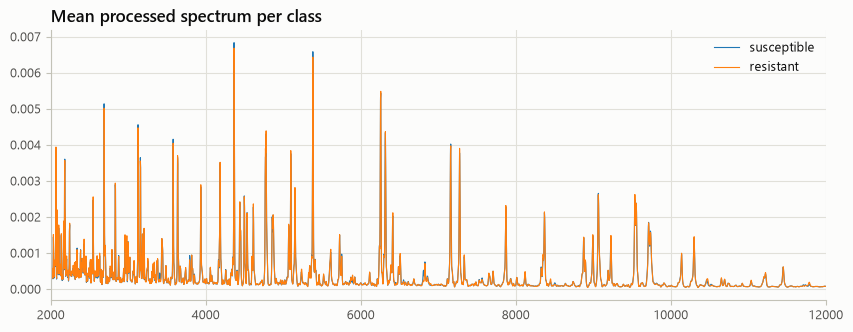

In [5]:
labels = meta['label'].to_numpy()
mean_r = np.zeros(X.shape[1])
mean_s = np.zeros(X.shape[1])
for start in range(0, len(meta), 512):          # chunked, so the whole matrix is never loaded
    block = np.asarray(X[start:start + 512], dtype=np.float64)
    lab = labels[start:start + 512]
    mean_r += block[lab == 1].sum(axis=0)
    mean_s += block[lab == 0].sum(axis=0)
mean_r /= (labels == 1).sum()
mean_s /= (labels == 0).sum()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(pcfg.bin_centers, mean_s, lw=0.8, label='susceptible')
ax.plot(pcfg.bin_centers, mean_r, lw=0.8, label='resistant')
ax.set_xlim(2000, 12000)
ax.legend()
ax.set_title('Mean processed spectrum per class')

## 5. Splits (indices only; patient groups kept together)

In [6]:
rows = []
for name, split in load_splits(data_dir / 'splits', meta).items():   # checks fingerprint and overlap
    s = split.summary(meta)
    for p in ('train', 'validation', 'test'):
        rows.append({'split': name, 'part': p,
                     **{k: s[p][k] for k in ('samples', 'resistant', 'susceptible', 'date_min', 'date_max')}})
pd.DataFrame(rows)

,split,part,samples,resistant,susceptible,date_min,date_max
0,random,train,2977,677,2300,2015-11-20,2018-08-31
1,random,validation,426,97,329,2015-12-07,2018-08-30
2,random,test,856,197,659,2015-11-20,2018-08-31
3,within_year,train,1284,300,984,2017-01-02,2017-12-30
4,within_year,validation,183,43,140,2017-01-02,2017-12-28
5,within_year,test,366,85,281,2017-01-02,2017-12-30
6,temporal,train,2505,568,1937,2015-11-20,2017-09-30
7,temporal,validation,465,110,355,2017-10-02,2017-12-30
8,temporal,test,1233,271,962,2018-01-03,2018-08-31
9,external,train,3831,873,2958,2015-11-20,2018-08-31
